In [1]:
import joblib
import pandas as pd

def predict_with_loaded_model(user_input):
    # تحميل النموذج المحفوظ
    model = joblib.load("svm_income_model.joblib")
    
    # تحويل الدخل لبيانات DataFrame
    input_df = pd.DataFrame([user_input])

    # عمل توقع واحتمالات
    probabilities = model.predict_proba(input_df)[0]
    return {
        "<=50K": round(probabilities[0] * 100, 2),
        ">50K": round(probabilities[1] * 100, 2)
    }


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
user_input = {
    "age": 22,
    "workclass": "Private",
    "fnlwgt": 5004,
    "education": "some-college",
    "education.num": 4,
    "marital.status": "Never-married",
    "occupation": "Handlers-cleaners",
    "relationship": "Unmarried",
    "race": "White",
    "sex": "Female",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 14,
    "native.country": "Thailand"
}

result = predict_with_loaded_model(user_input)
print(result)


{'<=50K': 89.28, '>50K': 10.72}


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5

In [9]:
import requests

user_input = {
    "age": 90,
    "workclass": "Private",
    "fnlwgt": 5004,
    "education": "some-college",
    "education.num": 4,
    "marital.status": "Never-married",
    "occupation": "Handlers-cleaners",
    "relationship": "Unmarried",
    "race": "White",
    "sex": "Female",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 14,
    "native.country": "Thailand"
}

response = requests.post("http://127.0.0.1:5000/predict", json=user_input)
print(response.json())


{'<=50K': 87.67, '>50K': 12.33}


In [10]:
import pandas as pd

df = pd.read_csv('adult.csv')
df.replace('?', pd.NA, inplace=True)  # استبدال ? بالقيم المفقودة
df.dropna(inplace=True)  # حذف الصفوف اللي فيها قيم مفقودة لو بتحب


In [11]:
summary = df.describe(include='all')
print(summary)


                 age workclass        fnlwgt education  education.num  \
count   30162.000000     30162  3.016200e+04     30162   30162.000000   
unique           NaN         7           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22286           NaN      9840            NaN   
mean       38.437902       NaN  1.897938e+05       NaN      10.121312   
std        13.134665       NaN  1.056530e+05       NaN       2.549995   
min        17.000000       NaN  1.376900e+04       NaN       1.000000   
25%        28.000000       NaN  1.176272e+05       NaN       9.000000   
50%        37.000000       NaN  1.784250e+05       NaN      10.000000   
75%        47.000000       NaN  2.376285e+05       NaN      13.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

            marital.status      occupation relationship   race    sex  \
count                30162           30162        

In [12]:
income_dist = df['income'].value_counts(normalize=True) * 100
print(income_dist)


income
<=50K    75.107751
>50K     24.892249
Name: proportion, dtype: float64


In [13]:
income_by_sex = df.groupby('sex')['income'].value_counts(normalize=True).unstack() * 100
print(income_by_sex)


income      <=50K       >50K
sex                         
Female  88.632182  11.367818
Male    68.616290  31.383710


In [14]:
income_by_edu = df.groupby('education')['income'].value_counts(normalize=True).unstack().fillna(0) * 100
print(income_by_edu.sort_values(">50K", ascending=False))


income             <=50K       >50K
education                          
Prof-school    25.092251  74.907749
Doctorate      25.333333  74.666667
Masters        43.577136  56.422864
Bachelors      57.850912  42.149088
Assoc-voc      73.680184  26.319816
Assoc-acdm     74.603175  25.396825
Some-college   79.994010  20.005990
HS-grad        83.567073  16.432927
12th           92.307692   7.692308
10th           92.804878   7.195122
7th-8th        93.716338   6.283662
11th           94.370229   5.629771
9th            94.505495   5.494505
5th-6th        95.833333   4.166667
1st-4th        96.026490   3.973510
Preschool     100.000000   0.000000


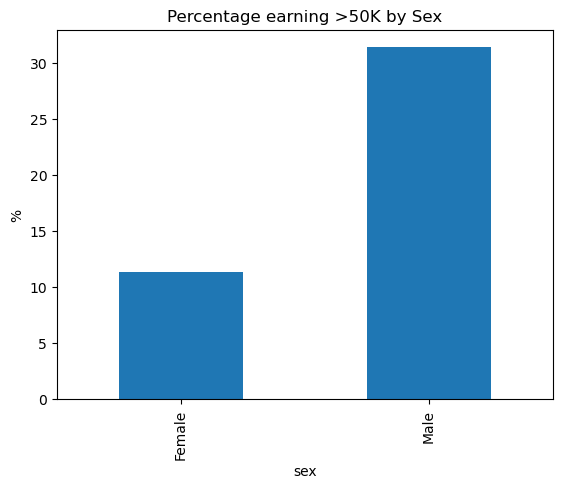

In [15]:
import matplotlib.pyplot as plt

income_by_sex[">50K"].plot(kind="bar", title="Percentage earning >50K by Sex")
plt.ylabel("%")
plt.show()


In [16]:
correlation = df.select_dtypes(include=['int64', 'float64']).corr()
print(correlation)


                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076511       0.043526      0.080154      0.060165   
fnlwgt         -0.076511  1.000000      -0.044992      0.000422     -0.009750   
education.num   0.043526 -0.044992       1.000000      0.124416      0.079646   
capital.gain    0.080154  0.000422       0.124416      1.000000     -0.032229   
capital.loss    0.060165 -0.009750       0.079646     -0.032229      1.000000   
hours.per.week  0.101599 -0.022886       0.152522      0.080432      0.052417   

                hours.per.week  
age                   0.101599  
fnlwgt               -0.022886  
education.num         0.152522  
capital.gain          0.080432  
capital.loss          0.052417  
hours.per.week        1.000000  


=== Testing /predict ===
Prediction Result: {'<=50K': 61.6, '>50K': 38.4}

=== Testing /eda ===
Income Distribution: {'<=50K': 75.11, '>50K': 24.89}
Correlation (age/hours): 0.102
Displaying plot: correlation_heatmap


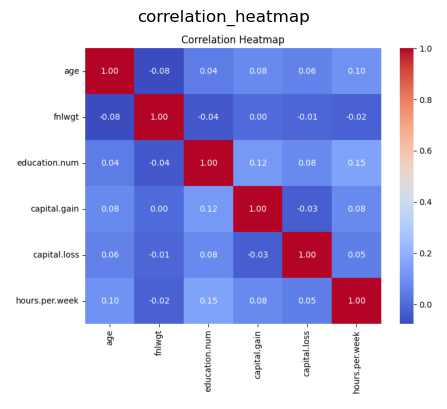

Displaying plot: income_by_education


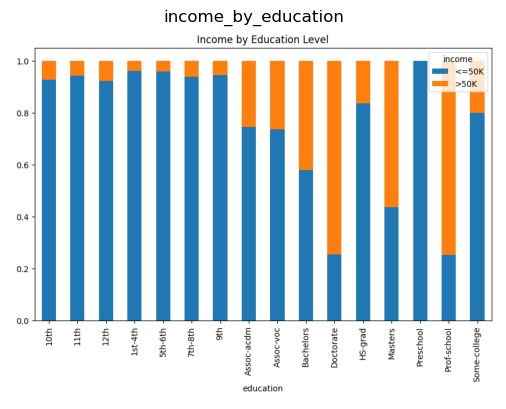

Displaying plot: income_by_sex


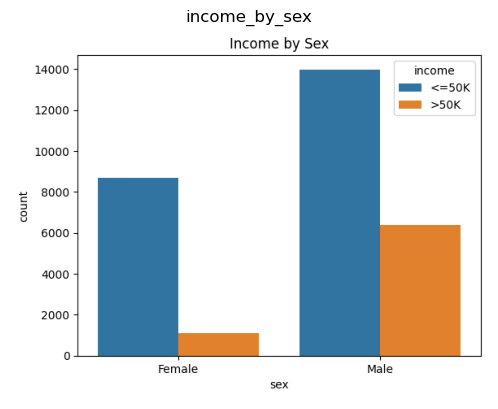

Displaying plot: income_distribution


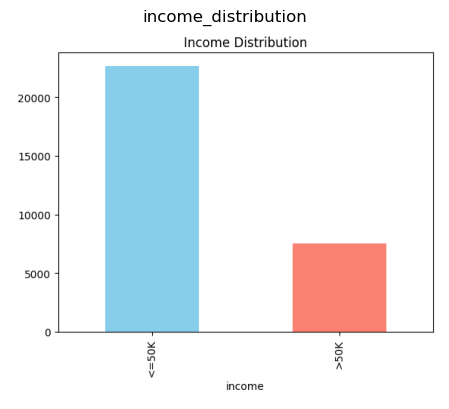

In [18]:
import requests
import base64
import matplotlib.pyplot as plt
from io import BytesIO

# عنوان السيرفر
base_url = "http://127.0.0.1:5000"

# ========== 1. اختبار /predict ==========

sample_input = {
    "age": 37,
    "workclass": "Private",
    "fnlwgt": 284582,
    "education": "HS-grad",
    "education.num": 9,
    "marital.status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 45,
    "native.country": "United-States"
}

print("=== Testing /predict ===")
predict_response = requests.post(f"{base_url}/predict", json=sample_input)

if predict_response.status_code == 200:
    print("Prediction Result:", predict_response.json())
else:
    print("Prediction Error:", predict_response.text)

# ========== 2. اختبار /eda ==========

print("\n=== Testing /eda ===")
eda_response = requests.get(f"{base_url}/eda")

if eda_response.status_code == 200:
    eda_data = eda_response.json()
    
    print("Income Distribution:", eda_data["income_distribution"])
    print("Correlation (age/hours):", eda_data["correlation"].get("age", {}).get("hours.per.week"))

    # عرض الرسوم البيانية
    for title, base64_str in eda_data["plots"].items():
        print(f"Displaying plot: {title}")
        img_data = base64.b64decode(base64_str)
        img = BytesIO(img_data)
        image = plt.imread(img, format='png')
        plt.figure()
        plt.title(title)
        plt.imshow(image)
        plt.axis('off')
        plt.show()
else:
    print("EDA Error:", eda_response.text)
